In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [2]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [3]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng']


In [4]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [5]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [6]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


In [7]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [8]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [9]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [10]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [11]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [12]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

In [13]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

In [14]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [15]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [17]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [18]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [19]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [20]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [22]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [23]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [24]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [25]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [26]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:37<00:00,  9.98it/s, loss=2.07]


Epoch 1/10, Train Loss: 3.0560


Epoch 2: 100%|██████████| 375/375 [00:37<00:00,  9.92it/s, loss=1.26]


Epoch 2/10, Train Loss: 1.5232


Epoch 3: 100%|██████████| 375/375 [00:38<00:00,  9.76it/s, loss=1.02] 


...

Epoch 8/10, Train Loss: 0.2194


Epoch 9: 100%|██████████| 375/375 [00:39<00:00,  9.60it/s, loss=0.293] 


Epoch 9/10, Train Loss: 0.2087


Epoch 10: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.145] 

Epoch 10/10, Train Loss: 0.2026
CPU times: user 6min 25s, sys: 4.3 s, total: 6min 29s
Wall time: 6min 27s


In [27]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [28]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:39<00:00,  9.58it/s, loss=0.213] 


Epoch 1/20, Train Loss: 0.2007, Validation Loss: 1.7394


Epoch 2: 100%|██████████| 375/375 [00:39<00:00,  9.59it/s, loss=0.193] 


Epoch 2/20, Train Loss: 0.1981, Validation Loss: 1.7653


Epoch 3: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.173] 


...

Epoch 18/20, Train Loss: 0.1718, Validation Loss: 1.9500


Epoch 19: 100%|██████████| 375/375 [00:38<00:00,  9.62it/s, loss=0.234] 


Epoch 19/20, Train Loss: 0.1719, Validation Loss: 1.9584


Epoch 20: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.283] 


Epoch 20/20, Train Loss: 0.1717, Validation Loss: 1.9676
CPU times: user 14min 10s, sys: 8.61 s, total: 14min 19s
Wall time: 14min 13s


In [29]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [30]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [31]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'r', 'o', 'se', 'pus', 'o', 'a', 'todo', 'el', 'mu', 'ndo', '.', '']


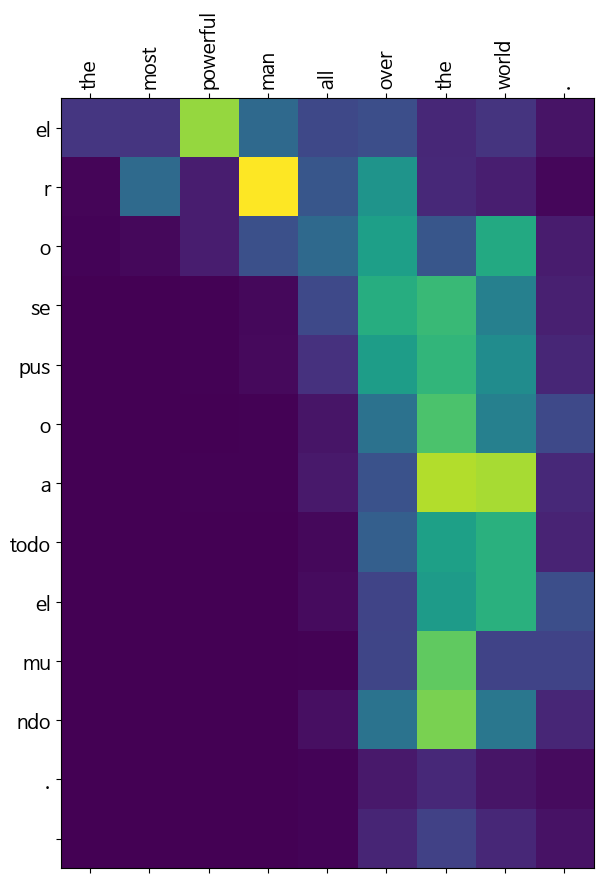

In [32]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['te', 'pued', 'o', 'ayudar', '?', '']


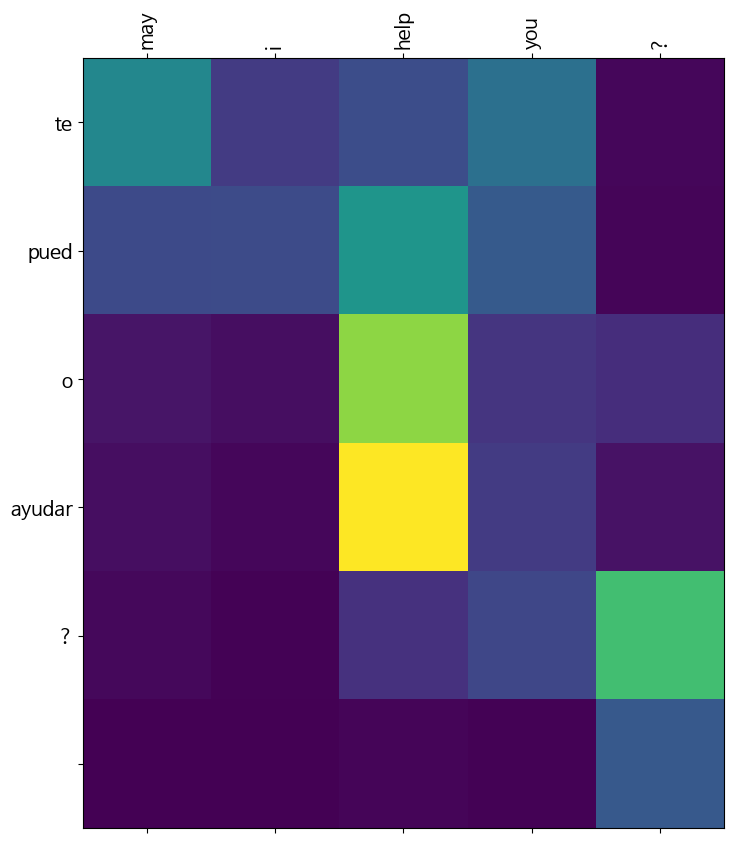

In [33]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['me', 'dan', 'un', 'c', 'af', '?', '']


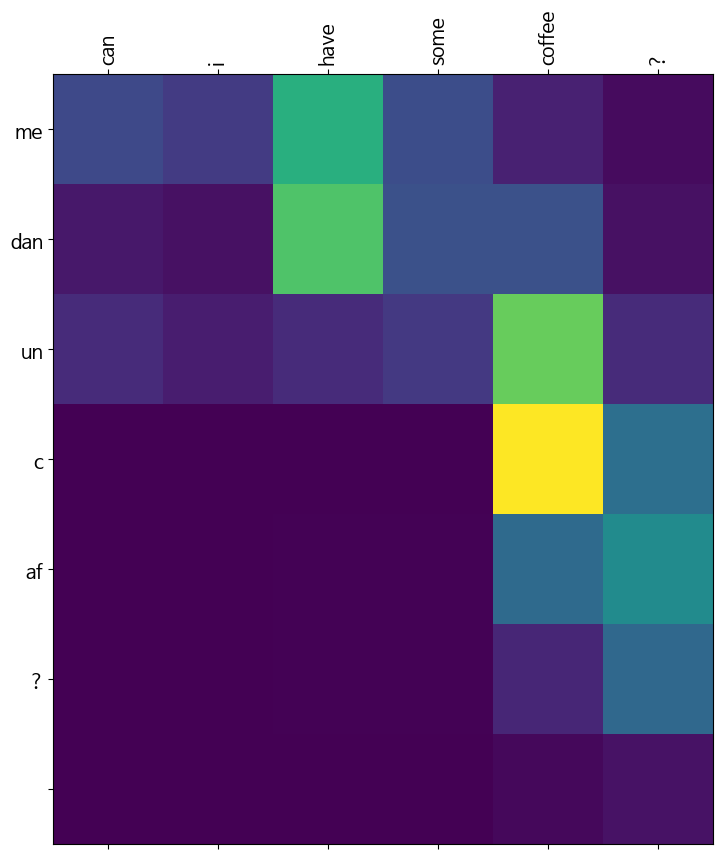

In [34]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [ ]:
!apt-get update
!apt-get install -y g++ curl
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [47]:
import os
import tarfile
import urllib.request
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import random

# Mecab을 불러옵니다
from mecab import MeCab 

# ------------------------------------------------
# Step 1. 데이터 다운로드
# ------------------------------------------------
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_path = "korean-english-park.train.tar.gz"

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(filter='data')
    
with open("korean-english-park.train.ko", "r", encoding="utf-8") as f:
    raw_kor = f.read().splitlines()
with open("korean-english-park.train.en", "r", encoding="utf-8") as f:
    raw_eng = f.read().splitlines()

print(f"[데이터 다운로드 확인] 원본 데이터 크기: 한국어 {len(raw_kor)}개, 영어 {len(raw_eng)}개")

# ------------------------------------------------
# Step 2. 데이터 정제
# ------------------------------------------------
cleaned_corpus = list(set(zip(raw_kor, raw_eng)))
print(f"[데이터 정제 확인] 중복 제거 후 데이터 크기: {len(cleaned_corpus)}개")

def preprocess_korean(sentence):
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    return sentence.strip()

def preprocess_english(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    return f"<start> {sentence.strip()} <end>"

# 🔥 대문자 C에 주의하세요!
mecab = MeCab()
kor_corpus = []
eng_corpus = []

print("데이터 전처리 및 토큰화 진행 중... (python-mecab-ko 사용)")
for ko, en in tqdm(cleaned_corpus):
    ko_pre = preprocess_korean(ko)
    en_pre = preprocess_english(en)
    
    # 형태소 분석이 작동할 것입니다!
    ko_tokens = mecab.morphs(ko_pre)
    en_tokens = en_pre.split()
    
    if len(ko_tokens) <= 40 and len(en_tokens) <= 40:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(en_tokens)

print(f"\n[데이터 정제 완료] 길이 40 이하 필터링 후 크기: {len(kor_corpus)}개")
print(f"[데이터 정제 확인] 전처리/토큰화 예시 (한국어): {kor_corpus[0]}")
print(f"[데이터 정제 확인] 전처리/토큰화 예시 (영  어): {eng_corpus[0]}")

[데이터 다운로드 확인] 원본 데이터 크기: 한국어 94123개, 영어 94123개
[데이터 정제 확인] 중복 제거 후 데이터 크기: 78968개
데이터 전처리 및 토큰화 진행 중... (python-mecab-ko 사용)


100%|██████████| 78968/78968 [00:27<00:00, 2843.23it/s]


[데이터 정제 완료] 길이 40 이하 필터링 후 크기: 61541개
[데이터 정제 확인] 전처리/토큰화 예시 (한국어): ['크', '게', '서두르', '는', '시간', '은', '주로', '점심', '시간', '인', '반면', ',', '많', '은', '사람', '들', '이', '아침', '식사', '와', '저녁', '식사', '에', '는', '시간', '을', '할애', '합니다', '.']
[데이터 정제 확인] 전처리/토큰화 예시 (영  어): ['<start>', 'the', 'big', 'rush', 'is', 'mainly', 'at', 'lunchtime', ',', 'with', 'many', 'people', 'taking', 'time', 'out', 'for', 'breakfast', 'and', 'supper', '.', '<end>']


In [48]:
from collections import Counter

# ------------------------------------------------
# Step 3. 데이터 토큰화
# ------------------------------------------------
class SimpleTokenizer:
    def __init__(self, num_words):
        self.num_words = num_words
        # 특수 토큰 예약
        self.word2idx = {'<pad>':0, '<unk>':1, '<start>':2, '<end>':3}
        self.idx2word = {0:'<pad>', 1:'<unk>', 2:'<start>', 3:'<end>'}
        
    def fit(self, corpus):
        word_counts = Counter()
        for tokens in corpus:
            word_counts.update(tokens)
            
        # 가장 빈도가 높은 단어들로 단어장 채우기
        most_common = word_counts.most_common(self.num_words - 4)
        for i, (word, _) in enumerate(most_common):
            self.word2idx[word] = i + 4
            self.idx2word[i + 4] = word
            
    def texts_to_sequences(self, corpus):
        return [[self.word2idx.get(w, self.word2idx['<unk>']) for w in tokens] for tokens in corpus]

def tokenize(corpus, vocab_size=10000, max_len=40):
    tokenizer = SimpleTokenizer(vocab_size)
    tokenizer.fit(corpus)
    
    sequences = tokenizer.texts_to_sequences(corpus)
    
    # 패딩 (길이를 max_len으로 맞춤)
    padded_tensor = []
    for seq in sequences:
        if len(seq) < max_len:
            seq = seq + [0] * (max_len - len(seq))
        padded_tensor.append(seq[:max_len])
        
    return torch.tensor(padded_tensor), tokenizer

VOCAB_SIZE = 12000 # 최소 10,000 이상!
kor_tensor, kor_tokenizer = tokenize(kor_corpus, vocab_size=VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, vocab_size=VOCAB_SIZE)

print(f"[토큰화 확인] 한국어 텐서 shape: {kor_tensor.shape}")
print(f"[토큰화 확인] 영문 텐서 shape: {eng_tensor.shape}")
print(f"[토큰화 확인] 영문 텐서 첫번째 샘플: {eng_tensor[0]}")

# DataLoader 구축 (검증 데이터 분리 없이 전체 사용)
BATCH_SIZE = 64
dataset = torch.utils.data.TensorDataset(kor_tensor, eng_tensor)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

[토큰화 확인] 한국어 텐서 shape: torch.Size([61541, 40])
[토큰화 확인] 영문 텐서 shape: torch.Size([61541, 40])
[토큰화 확인] 영문 텐서 첫번째 샘플: tensor([   6,    4,  408, 4418,   19, 2490,   23,    1,    8,   21,  148,   44,
         421,   80,   71,   16, 4553,   13,    1,    5,    7,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


In [49]:
# ------------------------------------------------
# Step 4. 모델 설계
# ------------------------------------------------
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return nn.functional.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        a = self.attention(hidden[-1], encoder_outputs)
        
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)
        
        output, hidden = self.rnn(embedded, hidden)
        
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40):
        batch_size = src.shape[1]
        outputs = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # Teacher Forcing
            for t in range(0, trg.shape[0]):
                input_tok = trg[t]
                output, hidden, attention = self.decoder(input_tok, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # Inference (Inference시에는 <start> 토큰(2)로 시작)
            input_tok = torch.full((batch_size,), 2, dtype=torch.long, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input_tok, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                input_tok = output.argmax(1)

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EMB_DIM = 256
HID_DIM = 512

encoder = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print("\n[모델 설계 완료] Seq2Seq Attention 모델 구조 준비")


[모델 설계 완료] Seq2Seq Attention 모델 구조 준비


In [50]:
# ------------------------------------------------
# Step 5. 훈련하기 및 예측 생성
# ------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# 패딩 토큰(0)은 손실 함수 계산에서 무시
criterion = nn.CrossEntropyLoss(ignore_index=0) 

def translate_sentence(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 전처리 및 토큰화
    ko_pre = preprocess_korean(sentence)
    tokens = mecab.morphs(ko_pre)
    
    # 인덱스 변환 및 텐서화
    indices = [kor_tokenizer.word2idx.get(w, 1) for w in tokens]
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        
    src_tensor = torch.tensor(indices).unsqueeze(1).to(device) # (src_len, 1)
    
    with torch.no_grad():
        # trg=None을 주어 Inference 모드로 실행
        outputs, _ = model(src_tensor, trg=None, max_len=max_len) 
    
    # 번역된 결과 디코딩
    output_idx = outputs.argmax(2).squeeze(1).tolist()
    
    translated = []
    for idx in output_idx:
        word = eng_tokenizer.idx2word[idx]
        if word == '<end>':
            translated.append(word)
            break
        if word not in ['<pad>', '<start>']:
            translated.append(word)
            
    return " ".join(translated)

def train_step_and_translate(model, data_loader, optimizer, criterion, epochs=10):
    test_sentences = [
        "오바마는 대통령이다.",
        "시민들은 도시 속에 산다.",
        "커피는 필요 없다.",
        "일곱 명의 사망자가 발생했다."
    ]
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)
        
        for src, trg in progress_bar:
            # (batch_size, seq_len) -> (seq_len, batch_size) 형태로 transpose
            src = src.permute(1, 0).to(device)
            trg = trg.permute(1, 0).to(device)
            
            optimizer.zero_grad()
            
            # 훈련 시 입력은 <end> 토큰 전까지만, 라벨은 <start> 토큰 이후부터
            trg_input = trg[:-1, :]
            trg_label = trg[1:, :]
            
            outputs, _ = model(src, trg_input)
            
            # 손실 계산을 위해 형태 변경
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)
            
            loss = criterion(outputs, trg_label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
            
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        print(f"Epoch {epoch+1} / Train Loss: {epoch_loss / len(data_loader):.4f}")
        
        # 매 에폭이 끝날 때마다 예문 번역 실행
        print("-" * 50)
        print("💡 [현재 에폭 번역 결과]")
        for i, sentence in enumerate(test_sentences):
            translation = translate_sentence(sentence, model, kor_tokenizer, eng_tokenizer)
            print(f"K{i+1}) {sentence}")
            print(f"E{i+1}) {translation}")
        print("-" * 50)

# 학습 시작 (테스트를 위해 epochs 수는 환경에 맞게 조절하세요)
train_step_and_translate(model, train_loader, optimizer, criterion, epochs=15)

Epoch 1: 100%|██████████| 962/962 [03:40<00:00,  4.37it/s, loss=4.3] 


Epoch 1 / Train Loss: 5.0417
--------------------------------------------------
💡 [현재 에폭 번역 결과]
K1) 오바마는 대통령이다.
E1) obama is president obama president obama is president obama . <end>
K2) 시민들은 도시 속에 산다.
E2) officials are <unk> . <end>
K3) 커피는 필요 없다.
E3) is not easy to be the <unk> . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) killed people . <end>
--------------------------------------------------


Epoch 2: 100%|██████████| 962/962 [03:39<00:00,  4.38it/s, loss=3.85]


Epoch 2 / Train Loss: 3.8771
--------------------------------------------------
💡 [현재 에폭 번역 결과]
K1) 오바마는 대통령이다.
E1) obama is the president . <end>
K2) 시민들은 도시 속에 산다.
E2) observers <unk> . <end>
K3) 커피는 필요 없다.
E3) coffee no need to be . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) deaths . <end>
--------------------------------------------------


Epoch 3: 100%|██████████| 962/962 [03:39<00:00,  4.37it/s, loss=3.23]


...

Epoch 13 / Train Loss: 0.8705
--------------------------------------------------
💡 [현재 에폭 번역 결과]
K1) 오바마는 대통령이다.
E1) obama is president of obama . <end>
K2) 시민들은 도시 속에 산다.
E2) civil administration on the town center went into <end>
K3) 커피는 필요 없다.
E3) coffee good need to take no way . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) seven people <end>
--------------------------------------------------


Epoch 14: 100%|██████████| 962/962 [03:39<00:00,  4.38it/s, loss=0.835]


Epoch 14 / Train Loss: 0.8099
--------------------------------------------------
💡 [현재 에폭 번역 결과]
K1) 오바마는 대통령이다.
E1) obama is president obama s inauguration . <end>
K2) 시민들은 도시 속에 산다.
E2) civil administration on the town s <unk> <end>
K3) 커피는 필요 없다.
E3) coffee no need to be necessary . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) seven massive rescue put the rest of the death . <end>
--------------------------------------------------


Epoch 15: 100%|██████████| 962/962 [03:39<00:00,  4.38it/s, loss=0.948]


Epoch 15 / Train Loss: 0.7602
--------------------------------------------------
💡 [현재 에폭 번역 결과]
K1) 오바마는 대통령이다.
E1) obama is president . <end>
K2) 시민들은 도시 속에 산다.
E2) civil administration on the town s <unk> <end>
K3) 커피는 필요 없다.
E3) coffee no need for . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) seven people <end>
--------------------------------------------------


모델 실행 결과:

- 핵심 단어 번역: 오바다-obama, 커피-coffee, 대통령-president 등 소스 언어와 타겟 언어 간의 핵십 단어 매핑은 잘 되는 것 같다.
- 문법 학습 부족: 단어의 뜻은 알지만 타겟 언어의 문법 구조를 잘 지키지는 못했다.
- 어휘 사전 한계: 희귀 단어 같은 것들이 나올 경우 unk토큰이 출력되거나 civil administration 같은 엉뚱한 단어가 출력되었다.

한국어를 영어로 번역이 완벽하게 실행되지는 않는다. 하지만 1에폭씩 학습 하면서 맥락은 잡아가는 것 같다.

원문: 시민들은 도시 속에 산다.
정답: people are victims of the city .


/tmp/ipykernel_272/3047139398.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + tokens[:input_len], fontproperties=fontprop, rotation=90)
/tmp/ipykernel_272/3047139398.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translated_tokens)


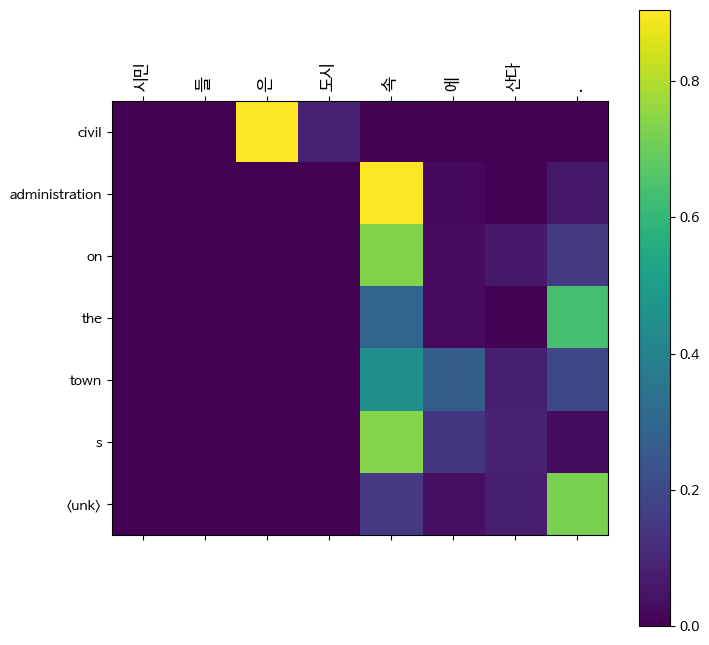

번역: civil administration on the town s <unk>

📊 BLEU Score: 0.0324


In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# (주의) 환경에 맞게 한글 폰트 경로를 설정해 주세요. 
# 코랩이나 우분투 환경의 기본 나눔고딕 경로입니다.
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
try:
    fontprop = fm.FontProperties(fname=fontpath, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
except:
    print("⚠️ 폰트를 찾을 수 없습니다. 그래프에 한글이 깨질 수 있습니다.")

def evaluate_and_visualize(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    ko_pre = preprocess_korean(sentence)
    tokens = mecab.morphs(ko_pre)
    
    indices = [kor_tokenizer.word2idx.get(w, 1) for w in tokens]
    input_len = len(indices)
    
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        input_len = max_len
        
    src_tensor = torch.tensor(indices).unsqueeze(1).to(device)
    
    # 2. 추론 및 어텐션 가중치 추출
    with torch.no_grad():
        # outputs: (max_len, 1, vocab_size), attentions: (max_len, 1, max_len)
        outputs, attentions = model(src_tensor, trg=None, max_len=max_len)
    
    output_idx = outputs.argmax(2).squeeze(1).tolist()
    attention_weights = attentions.squeeze(1).cpu().numpy() # (max_len, max_len)
    
    # 3. 디코딩 및 <end> 토큰 처리
    translated_tokens = []
    for idx in output_idx:
        word = eng_tokenizer.idx2word[idx]
        if word == '<end>':
            break
        if word not in ['<pad>', '<start>']:
            translated_tokens.append(word)
            
    result_sentence = " ".join(translated_tokens)
    
    # 실제 생성된 단어 길이만큼만 어텐션 맵 자르기
    output_len = len(translated_tokens)
    # attention_weights는 (출력 길이, 입력 길이) 로 슬라이싱
    attention_weights = attention_weights[:output_len, :input_len]
    
    # 4. Attention Map 시각화
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1)
    
    # 매트릭스 시각화 (밝을수록 높은 가중치)
    cax = ax.matshow(attention_weights, cmap='viridis')
    fig.colorbar(cax)
    
    # 축 설정
    ax.set_xticklabels([''] + tokens[:input_len], fontproperties=fontprop, rotation=90)
    ax.set_yticklabels([''] + translated_tokens)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    plt.show()
    
    return result_sentence, translated_tokens

# ------------------------------------------------
# 실행 및 평가 테스트
# ------------------------------------------------
test_sentence = "시민들은 도시 속에 산다."
reference_sentence = "people are victims of the city ." # 정답 예시 (단어 토큰 단위 리스트로 변환 필요)
reference_tokens = [reference_sentence.split()]

print(f"원문: {test_sentence}")
print(f"정답: {reference_sentence}")

# 번역 및 시각화
translated_sentence, translated_tokens = evaluate_and_visualize(test_sentence, model, kor_tokenizer, eng_tokenizer)
print(f"번역: {translated_sentence}")

# BLEU Score 계산
# smoothing function을 사용하여 짧은 문장에 대한 페널티를 완화합니다.
smoothie = SmoothingFunction().method4
bleu_score = sentence_bleu(reference_tokens, translated_tokens, smoothing_function=smoothie)

print(f"\n📊 BLEU Score: {bleu_score:.4f}")

시각화 해석 결과:

- 핵심 단어 무시: 모델이 단어를 생성할 때 중요한 단어는 확인하지 않고, 특정 좃